In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

def add_source(fig, text):
    """Write the data source under the chart."""
    fig.text(0.01, 0.005, text, fontsize=8, color="#666666", ha="left", va="bottom")

In [2]:
path = "https://raw.githubusercontent.com/AndrewEberhardt/DataScienceProject/main/data/raw/crops/beef-and-buffalo-meat-production-tonnes.csv"
cattle= pd.read_csv(path)
cattle.head() 

,Entity,Code,Year,Beef and buffalo meat - Production (tonnes)
0,Afghanistan,AFG,1961,43000.0
1,Afghanistan,AFG,1962,45800.0
2,Afghanistan,AFG,1963,47250.0
3,Afghanistan,AFG,1964,48000.0
4,Afghanistan,AFG,1965,48700.0


In [3]:
cattle_world = cattle[cattle["Entity"] == "World"].reset_index(drop=True)
cattle_world.head()


,Entity,Code,Year,Beef and buffalo meat - Production (tonnes)
0,World,OWID_WRL,1961,28753174.0
1,World,OWID_WRL,1962,30305242.0
2,World,OWID_WRL,1963,31973646.0
3,World,OWID_WRL,1964,32434628.0
4,World,OWID_WRL,1965,33038106.0


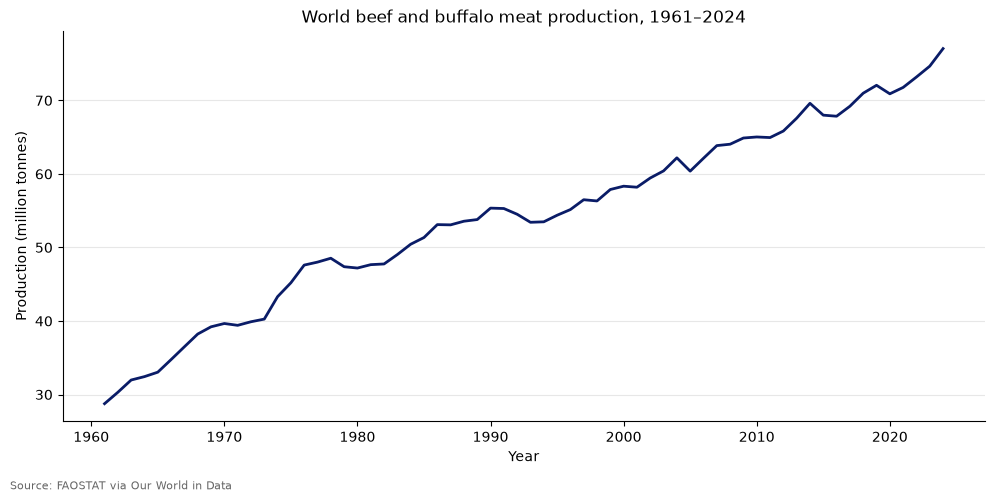

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cattle_world["Year"], cattle_world["Beef and buffalo meat - Production (tonnes)"] / 1e6, color="#0a1c67", linewidth=2)
ax.set_title("World beef and buffalo meat production, 1961–2024")
ax.set_xlabel("Year")
ax.set_ylabel("Production (million tonnes)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, "Source: FAOSTAT via Our World in Data")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

In [5]:
cattle_pays = cattle[cattle["Code"].notna() & ~cattle["Code"].str.startswith("OWID_")]

prod_par_pays = (
    cattle_pays.groupby("Entity")["Beef and buffalo meat - Production (tonnes)"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Entity": "pays", "Beef and buffalo meat - Production (tonnes)": "production_totale_t"})
)
prod_par_pays.head(20)

,pays,production_totale_t
0,United States,7.028479e+08
1,Brazil,3.135003e+08
2,China,1.929304e+08
3,Argentina,1.740239e+08
4,India,1.387956e+08
5,Australia,1.114606e+08
6,France,1.029362e+08
7,Germany,9.451882e+07
8,Mexico,7.843580e+07
9,Canada,6.817930e+07


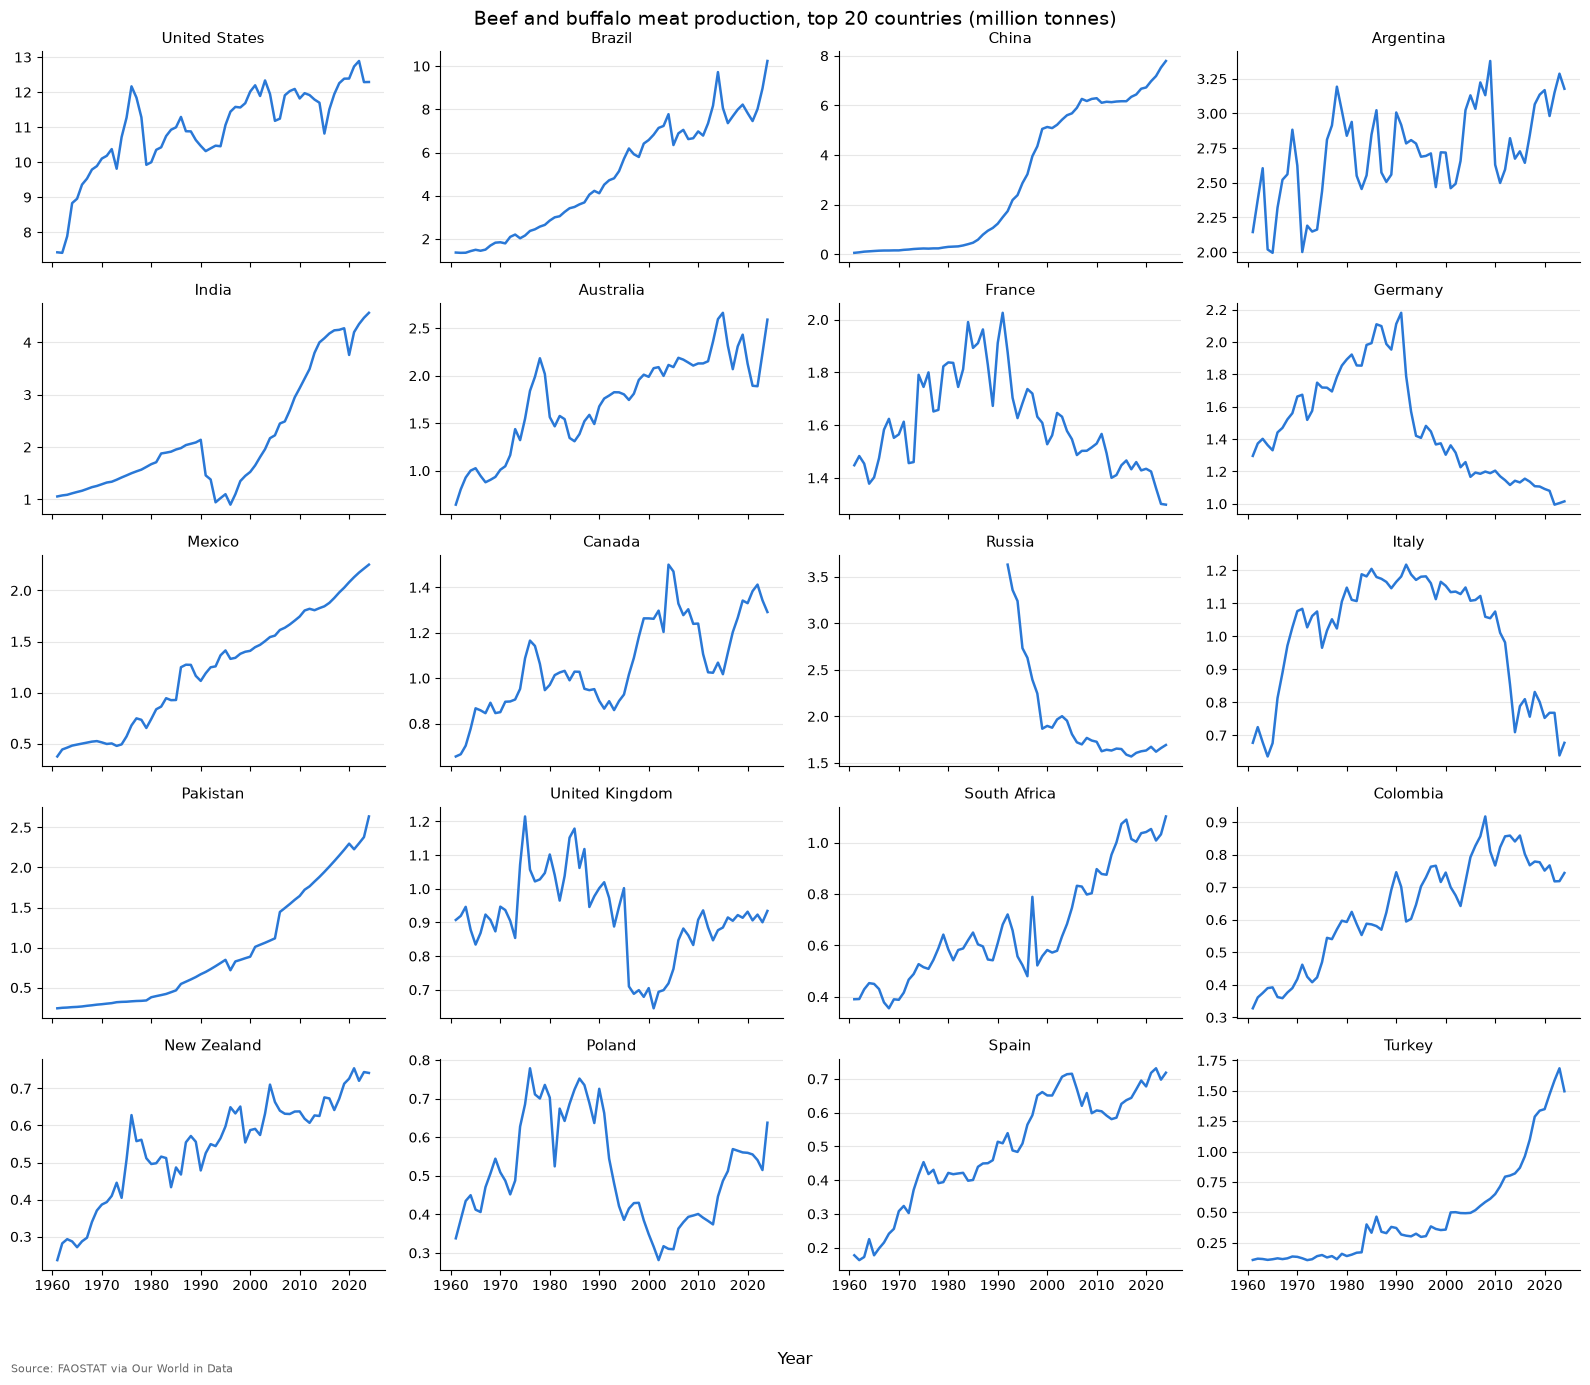

In [6]:
top20 = prod_par_pays.head(20)["pays"].tolist()
data = cattle_pays[cattle_pays["Entity"].isin(top20)]

fig, axes = plt.subplots(5, 4, figsize=(16, 14), sharex=True)
for ax, pays in zip(axes.flat, top20):
    d = data[data["Entity"] == pays]
    ax.plot(d["Year"], d["Beef and buffalo meat - Production (tonnes)"] / 1e6, color="#2a78d6", linewidth=1.8)
    ax.set_title(pays, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Beef and buffalo meat production, top 20 countries (million tonnes)", fontsize=14)
fig.supxlabel("Year")
add_source(fig, "Source: FAOSTAT via Our World in Data")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

In [7]:
prod_par_pays["part_%"] = prod_par_pays["production_totale_t"] / prod_par_pays["production_totale_t"].sum() * 100
prod_par_pays.head

<bound method NDFrame.head of                   pays  production_totale_t     part_%
0        United States         7.028479e+08  21.825165
1               Brazil         3.135003e+08   9.734958
2                China         1.929304e+08   5.990967
3            Argentina         1.740239e+08   5.403873
4                India         1.387956e+08   4.309947
..                 ...                  ...        ...
192         Seychelles         3.531540e+03   0.000110
193            Bahamas         2.870750e+03   0.000089
194  Equatorial Guinea         2.544080e+03   0.000079
195               Niue         4.636100e+02   0.000014
196       Cook Islands         3.416600e+02   0.000011

[197 rows x 3 columns]>

In [8]:
cattle_pays = cattle[cattle["Code"].notna()
                     & ~cattle["Code"].str.startswith("OWID_")
                     & (cattle["Year"] >= 1996)]

prod_par_pays = (
    cattle_pays.groupby("Entity")["Beef and buffalo meat - Production (tonnes)"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Entity": "pays", "Beef and buffalo meat - Production (tonnes)": "production_totale_t"})
)
prod_par_pays["part_%"] = prod_par_pays["production_totale_t"] / prod_par_pays["production_totale_t"].sum() * 100
prod_par_pays.head(20)


,pays,production_totale_t,part_%
0,United States,3.457954e+08,18.393538
1,Brazil,2.142331e+08,11.395477
2,China,1.721661e+08,9.157851
3,India,8.678400e+07,4.616211
4,Argentina,8.325157e+07,4.428314
5,Australia,6.236315e+07,3.317218
6,Russia,5.218117e+07,2.775619
7,Mexico,5.051400e+07,2.686939
8,Pakistan,4.660664e+07,2.479099
9,France,4.365556e+07,2.322125


In [9]:
n = (prod_par_pays["part_%"] > 1).sum()
print(n, "pays ont une part supérieure à 1 %")


21 pays ont une part supérieure à 1 %


Argentina', 'Australia', 'Bhutan', 'Brazil', 'Colombia', 'Congo', 'Dominican Republic', 'Fiji', 'Guinea', 'Kenya', 'Malawi', 'Malaysia', 'Mozambique', 'Nicaragua', 'Nigeria', 'Peru', 'South Africa', 'Sri Lanka', 'Suriname', 'Viet Nam'

In [10]:
gros = prod_par_pays[prod_par_pays["part_%"] > 1]
print(len(gros), "pays")
gros


21 pays


,pays,production_totale_t,part_%
0,United States,3.457954e+08,18.393538
1,Brazil,2.142331e+08,11.395477
2,China,1.721661e+08,9.157851
3,India,8.678400e+07,4.616211
4,Argentina,8.325157e+07,4.428314
5,Australia,6.236315e+07,3.317218
6,Russia,5.218117e+07,2.775619
7,Mexico,5.051400e+07,2.686939
8,Pakistan,4.660664e+07,2.479099
9,France,4.365556e+07,2.322125


In [11]:
gros_producteurs_cattle = prod_par_pays.loc[prod_par_pays["part_%"] > 1, "pays"].tolist()
gros_producteurs_cattle


['United States',
 'Brazil',
 'China',
 'India',
 'Argentina',
 'Australia',
 'Russia',
 'Mexico',
 'Pakistan',
 'France',
 'Canada',
 'Germany',
 'Italy',
 'South Africa',
 'United Kingdom',
 'Turkey',
 'Colombia',
 'Uzbekistan',
 'Egypt',
 'New Zealand',
 'Spain']

In [12]:
pays_cattle = ['Argentina', 'Australia', 'Bhutan', 'Brazil', 'Colombia', 'Congo', 'Dominican Republic',
               'Fiji', 'Guinea', 'Kenya', 'Malawi', 'Malaysia', 'Mozambique', 'Nicaragua', 'Nigeria',
               'Peru', 'South Africa', 'Sri Lanka', 'Suriname', 'Viet Nam', "Mexico"]

communs = sorted(set(pays_cattle) & set(gros_producteurs_cattle))
communs


['Argentina', 'Australia', 'Brazil', 'Colombia', 'Mexico', 'South Africa']

india is missing 

These country lists describe who produces the crop. They do not choose the sample of the analysis: the regressions use every country of the deforestation panel, weighted by its own exposure.

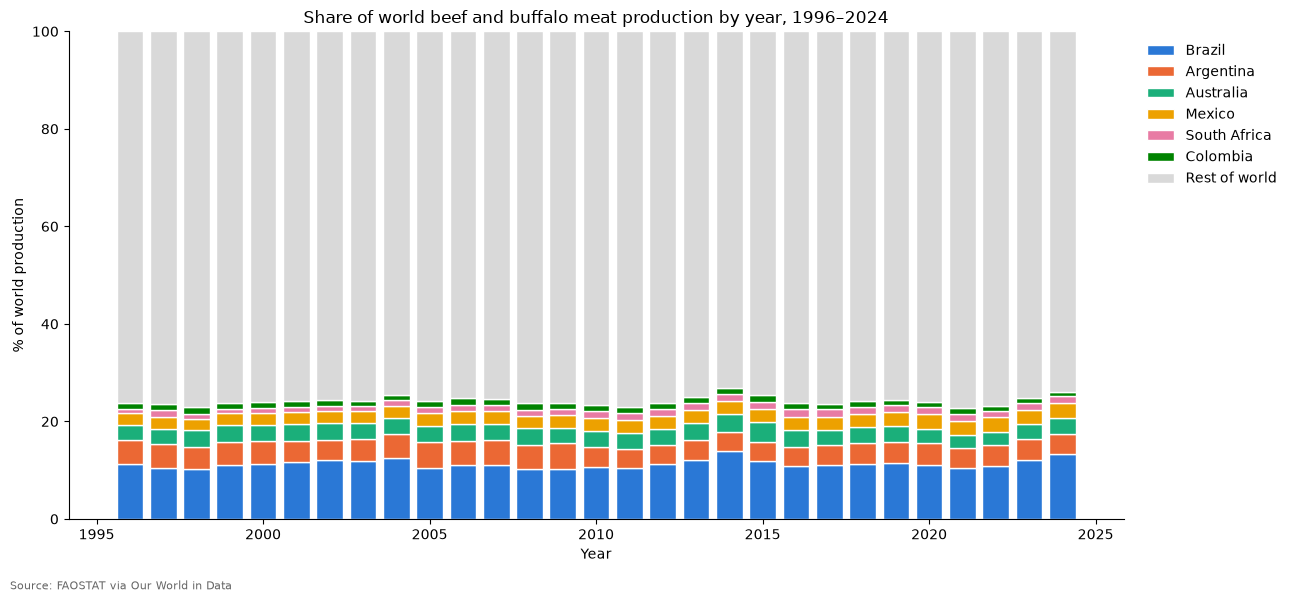

In [13]:
cattle_2= pd.read_csv(path)
col = "Beef and buffalo meat - Production (tonnes)"
pays_retenus = ["Brazil", "Argentina", "Australia", "Mexico", "South Africa", "Colombia"]

# Production par pays et par année, depuis 1996
cattle_96 = cattle_2[cattle_2["Year"] >= 1996]
monde = cattle_96[cattle_96["Entity"] == "World"].set_index("Year")[col]

parts = (cattle_96[cattle_96["Entity"].isin(pays_retenus)]
         .pivot(index="Year", columns="Entity", values=col)[pays_retenus]
         .div(monde, axis=0) * 100)
parts["Rest of world"] = 100 - parts.sum(axis=1)

couleurs = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#d9d9d9"]

fig, ax = plt.subplots(figsize=(13, 6))
bas = np.zeros(len(parts))
for p, c in zip(parts.columns, couleurs):
    ax.bar(parts.index, parts[p], bottom=bas, color=c, width=0.8,
           edgecolor="white", linewidth=1, label=p)
    bas += parts[p].values

ax.set_title("Share of world beef and buffalo meat production by year, 1996–2024")
ax.set_xlabel("Year")
ax.set_ylabel("% of world production")
ax.set_ylim(0, 100)
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, "Source: FAOSTAT via Our World in Data")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()
